In [1]:
import numpy as np

# import sasmodels
import sasmodels
import sasmodels.core
import sasmodels.data
import sasmodels.bumps_model

import sasdata

from sasdata.dataloader.loader import Loader
from sasmodels.data import load_data
#from sas import sascalc.dataloader

from sasmodels.data import plot_theory

import bumps
import bumps.fitters
import bumps.names
import bumps.fitproblem

import os

In [2]:
"""
import matplotlib.pyplot and set custom default settings for plots
"""
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import matplotlib.pyplot as plt

plt.rc('font', size=14) # default fontsize
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)
plt.rc('figure', titlesize=18)
plt.rc("figure", figsize=(5,5))
plt.rc("lines", linewidth=3)

# this one is for 2D SAXS images
plt.rc('image', cmap='jet')

In [5]:
filenameraw= "./data-examples/2_Pdm_norm_thick.dat"

In [6]:
fileempty="./data-examples/ctac_xmM_norm_thick.dat"

total number of data points:  1205


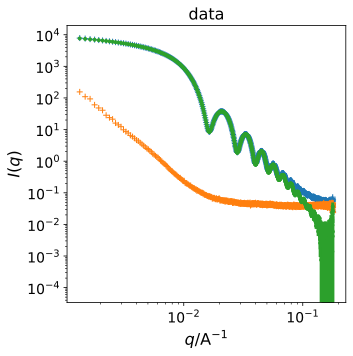

In [7]:
#number of lines in the header
skipheader=3

# Using loadtxt to load data
data_np = np.loadtxt(filenameraw, skiprows=skipheader)

total_data_number=data_np.shape[0] #total number of data points in the file
print('total number of data points: ',total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')
# datasub incorporates the subtraction of empty file
coeffempty=1.3
empty_np = np.loadtxt(fileempty, skiprows=skipheader)

plt.loglog(empty_np[:,0], empty_np[:,1], '+')
datasub= sasmodels.data.Data1D(x=data_np[0:total_data_number,0], 
                             y=data_np[0:total_data_number,1]-coeffempty*empty_np[0:total_data_number,1], 
                             dy=data_np[0:total_data_number,2])




sasmodels.data.plot_data(datasub)

In [10]:
subfilename=filenameraw[:-4]+"_sub.dat" # data 

with open(subfilename, "w") as f:
    f.write("raw data file is:"+filenameraw+"\n")
    f.write("number of data points: \t"+str(total_data_number)+"\n")

with open(subfilename, "a") as fa:
    for i in range(0,total_data_number):
        line_to_write=str(datasub.x[i])+"\t"+str(datasub.y[i])+"\t"+str(datasub.dy[i])+"\n"
        fa.write(line_to_write)

In [13]:
filename= "./data-examples/2_Pdm_norm_thick_sub.dat"
#filename='./data-examples/SWING-mn1-00169{00028}_AzInt_Px_28.dat'

#filename="./data-examples/0V_00228.dat"

total number of data points:  1157
after skip at low and large q values: 717
after slicing: 239


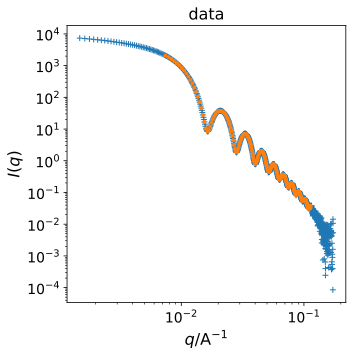

In [43]:
#number of lines in the header
skipheader=3 # 50 for a SWING data set

data_np = np.loadtxt(filename, skiprows=skipheader)

total_data_number=data_np.shape[0] #total number of data points in the file
print('total number of data points: ',total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')

#number of points to skip at low q values
skipmin=40
data_np = np.loadtxt(filename, skiprows=skipheader+skipmin)

# number of data point to skip at the end
skipmax=400
number_of_data=total_data_number-skipmax-skipmin

print('after skip at low and large q values:', number_of_data)

slicing_step=3 # step of slicing 

# rescaling of intensity values
# TP UE soft matter 2026
# scaling factor from SWING to Cu-SAXS to be in cm-1
rescale=1

# new error bars: 10 % of intensity values
coeff=0.1

#data = sasmodels.data.Data1D(x=data_np[:,0], y=data_np[:,1], dy=data_np[:,2])
data = sasmodels.data.Data1D(x=data_np[0:number_of_data:slicing_step,0], 
                             y=rescale*abs(data_np[0:number_of_data:slicing_step,1]), 
                             dy=rescale*coeff*abs(data_np[0:number_of_data:slicing_step,1]))

number_of_data_new=data.x.shape[0]
print('after slicing:', number_of_data_new)

sasmodels.data.plot_data(data)

In [47]:
newfilename=filename[:-4]+"_new.dat" # data 

with open(newfilename, "w") as f:
    f.write("raw data file is:"+filename+"\n")
    f.write("number of data points: \t"+str(number_of_data_new)+"\n")

with open(newfilename, "a") as fa:
    for i in range(0,number_of_data_new):
        line_to_write=str(data.x[i])+"\t"+str(data.y[i])+"\t"+str(data.dy[i])+"\n"
        fa.write(line_to_write)

In [48]:

kernel = sasmodels.core.load_model("sphere")
params = {} 
model = sasmodels.bumps_model.Model(kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

In [49]:

kernel.info.parameters.defaults

{'scale': 1,
 'background': 0.001,
 'sld': 1,
 'sld_solvent': 6,
 'radius': 50,
 'up_frac_i': 0.0,
 'up_frac_f': 0.0,
 'up_theta': 90.0,
 'up_phi': 0.0,
 'sld_M0': 0.0,
 'sld_mtheta': 0.0,
 'sld_mphi': 0.0,
 'sld_solvent_M0': 0.0,
 'sld_solvent_mtheta': 0.0,
 'sld_solvent_mphi': 0.0}

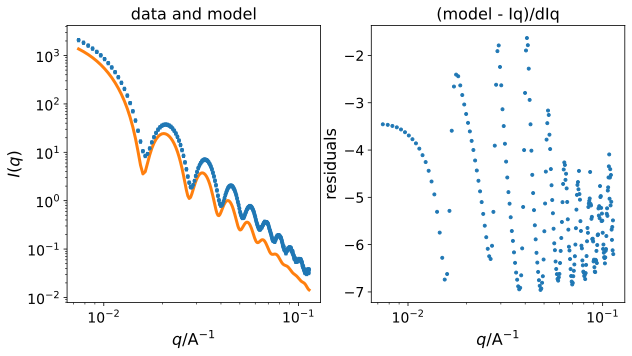

In [50]:
sld_silver=77.9
sld_gold=125
sld_platinum=136
sld_palladium=88.5
sld_rhodium=92.3
sld_water=9.47

params = {
    "radius": 280,                
    "radius_pd_type": 'gaussian',
    "radius_pd": 0.05,
    "radius_pd_n": 8,
    "radius_pd_nsigma": 4,
    "sld": sld_palladium,
    "sld_solvent": sld_water,
    "background": 0.0,
    "scale": 0.00006
}

model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

plt.figure(figsize=(10,5))
experiment.plot()

step 1 cost 28.989(15)
                                  radius ....|.....        280 in [250, 320]
                               radius_pd ....|.....       0.05 in [0.01, 0.1]
                                   scale |.........      6e-05 in [4e-06, 0.009]
step 6 cost 2.349(15) [final]
                                  radius ...|......        273 in [250, 320]
                               radius_pd ...|......  0.0453126 in [0.01, 0.1]
                                   scale |......... 0.000122959 in [4e-06, 0.009]
time 12.6 milliseconds
Fit results for problem: χ² = 2.349(15)
=== Uncertainty from curvature:     name   value(unc.) ===
                                  radius   273.00(22)     
                               radius_pd   0.04531(64)    
                                   scale   0.00012296(85) 
                                  radius ...|......        273 in [250, 320]
                               radius_pd ...|......  0.0453126 in [0.01, 0.1]
                    

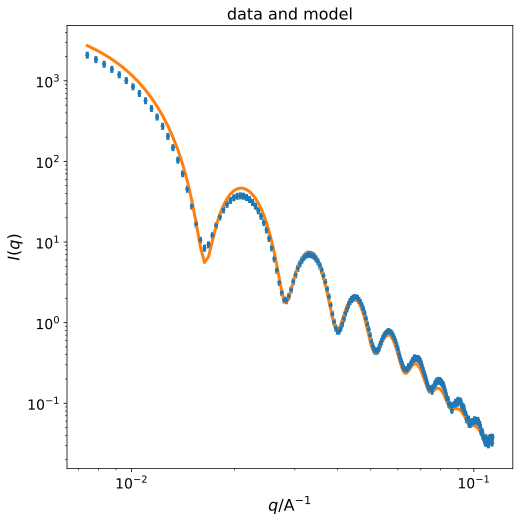

In [51]:
# list of the fitting parameters with their fitting range
model.scale.range(0.000004, 0.009)
model.radius.range(250, 320)
model.radius_pd.range(0.01, 0.1)



problem = bumps.fitproblem.FitProblem(experiment)

results = bumps.fitters.fit(problem, 
                            method='lm', 
                            steps=10, 
                            ftol=1.5e-06, 
                            xtol=1.5e-06, 
                            verbose=True)

plt.figure(figsize=(8,8))
print(problem.summarize())
print(model.state())
print(problem.chisq())
sasmodels.data.plot_theory(data, experiment.Iq_calc)

In [52]:
fitfilename=filename[:-4]+"_fit.dat" # fit 

with open(fitfilename, "w") as f:
    f.write("raw data file is:"+filename+"\n")
    f.write("number of data points: \t"+str(number_of_data_new)+"\n")

with open(fitfilename, "a") as fa:
    for i in range(0,number_of_data_new-1):
        line_to_write=str(data.x[i])+"\t"+str(experiment.Iq_calc[i])+"\n"
        fa.write(line_to_write)

In [55]:
qstart = data.x[0]

print(qstart)

qend = data.x[number_of_data_new-1]

print(qend)

Istart = data.y[0]

print(Istart)

Iend = data.y[number_of_data_new-1]

print(Iend)

0.00742332412889025
0.1134136623664422
2090.013947995711
0.037737584358870827


Text(0.02226997238667075, 0.11321275307661248, '$\\chi^2$ = 2.35')

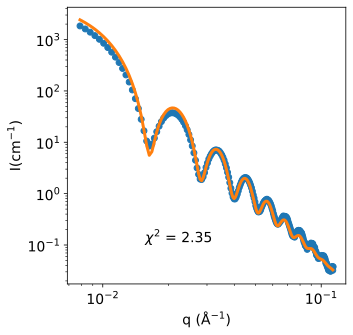

In [56]:
data_final = np.loadtxt(newfilename, skiprows=3)


fit_final = np.loadtxt(fitfilename, skiprows=3)


plt.loglog(data_final[:,0], data_final[:,1], 'o')

plt.loglog(fit_final[:,0], fit_final[:,1])

plt.xlabel('q '+r'(Å$^{-1}$)', fontsize=14)

plt.ylabel('I'+r'(cm$^{-1}$)', fontsize=14)

plt.text(qstart*3, Iend*3, r'$\chi^2$ = '+f"{problem.chisq():.2f}",

         fontsize=14, horizontalalignment='center')
